In [11]:
import sys
sys.path.append('..')
from general_settings import *
%reload_ext autoreload
%autoreload 2

In [13]:
c_expr = fn.Constant(c)
alpha = 0.1 # alpha = 0.3, 0.8
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2))
print(b)

b = 191.77/1e3
# b = 31.54/1e3
parameter = [c_expr, b, alpha]
# Number of eigenvalues:
k = 160

191.77359664498965


161


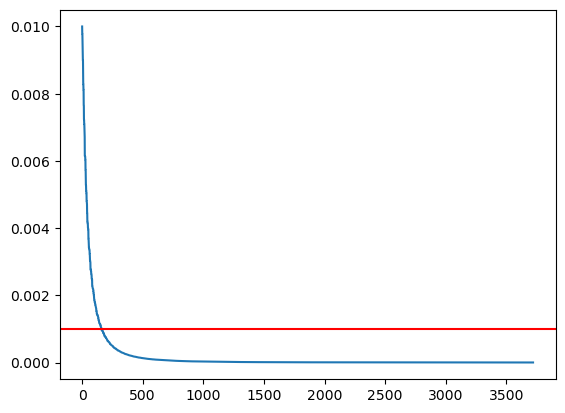

In [3]:
# Define priors:
gamma = 0.1
delta = 10.
L_form = fn.inner(fn.grad(u_trial), fn.grad(u_test)) * fn.dx
M_form = fn.inner(u_trial, u_test) * fn.dx
R_matrix = fn.assemble(gamma * L_form + delta * M_form)
R_array = R_matrix.array()
M_array = M_matrix.array()
eigvals_R, eigvecs_R = eigh(R_array, M_array)
eigvals_square = 1/eigvals_R ** 2

# Plot the eigenvalues:
plt.plot(eigvals_square)
# Draw the line y = 2 * 1e-3:
plt.axhline(y=1e-3, color='r', linestyle='-')
# Count the number of eigenvalues above the line:
print(np.sum(1/eigvals_R**2 > 1e-3))

(array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01,
        1.e+00]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

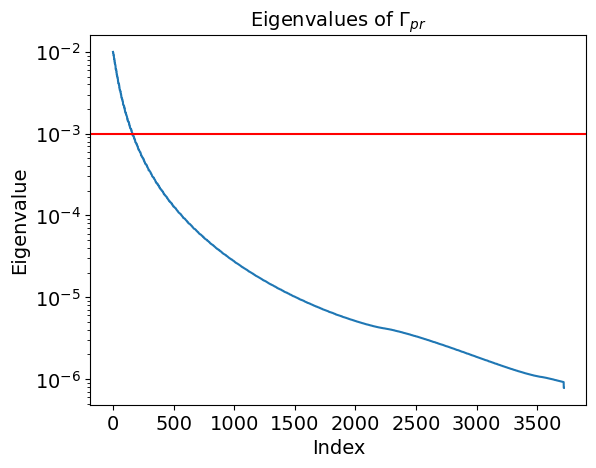

In [4]:
ax = plt.figure
plt.semilogy(eigvals_square)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Eigenvalue', fontsize=14)
plt.title('Eigenvalues of $\Gamma_{pr}$', fontsize=14)
plt.axhline(y=1e-3, color='r', linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Export plot to pdf with short marginal:
# plt.savefig('eigenvalues_laplacian.pdf', bbox_inches='tight')

In [5]:
def comp_FIM(multi_solution_1, multi_solution_2):
    n = len(multi_solution_1)
    FIM = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            FIM[i, j] = integrate_time_vectors(multi_solution_1[i], multi_solution_2[j], B_matrix, simulation_times)
            FIM[j, i] = FIM[i, j]
    return FIM

def comp_2(observations):
    result = []
    for i in range(len(observations)):
        for j in range(len(observations)):
            print('Compute FIM:', i, j)
            temp_result = comp_FIM(observations[i], observations[j])
            result.append(temp_result)
    return result

In [6]:
list_vectors = [init_vector_numpy(eigvecs_R[:, i]) for i in range(V.dim())]
omega = np.array([20 * np.pi, 30 * np.pi, 40 * np.pi, 50 * np.pi, 60 * np.pi])
size_omega = len(omega)
list_i_funcs = np.array([np.sin(omega[i] * simulation_times) for i in range(size_omega)])
list_i_prime_funcs = np.array([omega[i] * np.cos(omega[i] * simulation_times) for i in range(size_omega)])

In [7]:
L2_norm_list = np.array([simps(func * func, simulation_times) for func in list_i_funcs])
H1_norm_list = np.array([simps(func * func, simulation_times) for func in list_i_prime_funcs])
print('L2 norm of the functions: ', L2_norm_list)
print('H1 norm of the functions: ', H1_norm_list)

# Define reference input:
I_0 = 200.
X = np.array([200., 0., 0., 0., 0.])
i_func_ref = list_i_funcs.T.dot(X)
i_prime_func_ref = list_i_prime_funcs.T.dot(X)

# Compute L2 norm of the reference input:
L2_norm_ref = simps(i_func_ref * i_func_ref, simulation_times)
H1_norm_ref = simps(i_prime_func_ref * i_prime_func_ref, simulation_times)
print('L2 norm of the reference function: ', L2_norm_ref)
print('H1 norm of the reference function: ', H1_norm_ref)

L2 norm of the functions:  [0.05 0.05 0.05 0.05 0.05]
H1 norm of the functions:  [ 197.39208802  444.13219805  789.56835209 1233.70055014 1776.5287922 ]
L2 norm of the reference function:  2000.0000000000005
H1 norm of the reference function:  7895683.5208714865


In [8]:
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
B_matrix = fn.assemble(fn.inner(u_trial('+'), u_test('+')) * ds(1))

In [9]:
mult_solution_20 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[0])
list_20 = export_list_time_vectors('data_list/bi_08_20_103.pkl', mult_solution_20)
del mult_solution_20
gc.collect()

mult_solution_30 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[1])
list_30 = export_list_time_vectors('data_list/bi_08_30_103.pkl', mult_solution_30)
del mult_solution_30
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


0

In [10]:
mult_solution_40 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[2])
list_40 = export_list_time_vectors('data_list/bi_08_40_103.pkl', mult_solution_40)
del mult_solution_40
gc.collect()

Solve for t = 0.0


KeyboardInterrupt: 

In [11]:
mult_solution_50 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[3])
list_50 = export_list_time_vectors('data_list/bi_03_50_103.pkl', mult_solution_50)
del mult_solution_50
gc.collect()

mult_solution_60 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, list_i_prime_funcs[4])
list_60 = export_list_time_vectors('data_list/bi_03_60_103.pkl', mult_solution_60)
del mult_solution_60
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 
Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


0

In [9]:
# Additional function:
omega = 80 * np.pi
i_prime = omega * np.cos(omega * simulation_times)
mult_solution_80 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, i_prime)
list_80 = export_list_time_vectors('data_list/bi_03_80_103.pkl', mult_solution_80)
del mult_solution_80
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


0

In [10]:
omega = 100 * np.pi
i_prime = omega * np.cos(omega * simulation_times)
mult_solution_100 = MultipleFractionalWaveSolver(V, simulation_times, list_vectors[:k], parameter, i_prime)
list_100 = export_list_time_vectors('data_list/bi_03_100_103.pkl', mult_solution_100)
del mult_solution_100
gc.collect()

Solve for t = 0.0
Solve for t = 0.01
Solve for t = 0.02
Solve for t = 0.03
Solve for t = 0.04
Solve for t = 0.05
Solve for t = 0.06
Solve for t = 0.07
Solve for t = 0.08
Solve for t = 0.09
Solve for t = 0.1
 


8